In [ ]:
#crop_recommendation_system

In [1]:
!pip install -q requests pandas numpy matplotlib seaborn

import requests
import pandas as pd
import numpy as np
import time
import json
from datetime import datetime, timezone
from getpass import getpass
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
print("Libraries loaded.")

Libraries loaded.


In [2]:
OWM_API_KEY = getpass("Enter your OpenWeatherMap API key: ").strip()


if not OWM_API_KEY:
    raise ValueError("OpenWeatherMap API key is required. Get one free at https://openweathermap.org/api")


print("Keys captured for this session only (not stored in any file).")

Enter your OpenWeatherMap API key: ··········
Keys captured for this session only (not stored in any file).


In [3]:
def fetch_weather(city: str, api_key: str, units: str = "metric") -> dict:
    """
    Fetch current weather for `city` from OpenWeatherMap.
    Returns a flat dict of features, or a dict with an 'error' key on failure.
    Never raises — callers can check result['error'].
    """
    url = "https://api.openweathermap.org/data/2.5/weather"
    params = {"q": city, "appid": api_key, "units": units}

    try:
        resp = requests.get(url, params=params, timeout=10)
    except requests.exceptions.Timeout:
        return {"error": f"Timeout while contacting weather API for '{city}'."}
    except requests.exceptions.ConnectionError:
        return {"error": f"Network error while contacting weather API for '{city}'."}
    except requests.exceptions.RequestException as e:
        return {"error": f"Request failed for '{city}': {e}"}

    if resp.status_code == 401:
        return {"error": "Invalid or missing OpenWeatherMap API key."}
    if resp.status_code == 404:
        return {"error": f"City '{city}' not found. Check spelling, e.g. 'Sri Ganganagar,IN'."}
    if resp.status_code != 200:
        return {"error": f"Weather API returned status {resp.status_code} for '{city}'."}

    try:
        d = resp.json()
    except ValueError:
        return {"error": f"Could not parse weather API response for '{city}'."}

    main = d.get("main", {})
    wind = d.get("wind", {})
    sys_ = d.get("sys", {})
    weather_list = d.get("weather", [{}])
    weather0 = weather_list[0] if weather_list else {}
    coord = d.get("coord", {})
    rain = d.get("rain", {})
    clouds = d.get("clouds", {})

    def to_dt(unix_ts, tz_offset):
        if unix_ts is None:
            return np.nan
        try:
            return datetime.fromtimestamp(unix_ts, tz=timezone.utc).isoformat()
        except Exception:
            return np.nan

    tz_offset = d.get("timezone", 0)

    record = {
        "city": d.get("name", city),
        "country": sys_.get("country", np.nan),
        "latitude": coord.get("lat", np.nan),
        "longitude": coord.get("lon", np.nan),
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "temperature": main.get("temp", np.nan),
        "feels_like_temperature": main.get("feels_like", np.nan),
        "minimum_temperature": main.get("temp_min", np.nan),
        "maximum_temperature": main.get("temp_max", np.nan),
        "humidity": main.get("humidity", np.nan),
        "atmospheric_pressure": main.get("pressure", np.nan),
        "wind_speed": wind.get("speed", np.nan),
        "wind_direction": wind.get("deg", np.nan),
        "cloudiness": clouds.get("all", np.nan),
        "rainfall": rain.get("1h", rain.get("3h", 0)),
        "weather_condition": weather0.get("main", np.nan),
        "weather_description": weather0.get("description", np.nan),
        "visibility": d.get("visibility", np.nan),
        "sunrise": to_dt(sys_.get("sunrise"), tz_offset),
        "sunset": to_dt(sys_.get("sunset"), tz_offset),
        "error": None,
    }
    return record

print("fetch_weather() defined.")

fetch_weather() defined.


In [4]:
city_input = input("Enter city (e.g. Sri Ganganagar, Delhi, Jaipur, Mumbai, Lucknow, Kolkata): ").strip()

weather_record = fetch_weather(city_input, OWM_API_KEY)

if weather_record.get("error"):
    print("Weather fetch failed:", weather_record["error"])
    weather_df = pd.DataFrame()
else:
    weather_df = pd.DataFrame([weather_record]).drop(columns=["error"])
    print("Weather fetched successfully.")

weather_df

Enter city (e.g. Sri Ganganagar, Delhi, Jaipur, Mumbai, Lucknow, Kolkata): Bhopal
Weather fetched successfully.


,city,country,latitude,longitude,timestamp,temperature,feels_like_temperature,minimum_temperature,maximum_temperature,humidity,atmospheric_pressure,wind_speed,wind_direction,cloudiness,rainfall,weather_condition,weather_description,visibility,sunrise,sunset
0,Bhopal,IN,23.2667,77.4,2026-10-04T08:25:52.887309+00:00,33.13,33.56,33.13,33.13,38,1015,2.06,180,0,0,Clear,clear sky,10000,2026-10-04T00:42:48+00:00,2026-10-04T12:35:28+00:00


In [5]:
if not weather_df.empty:
    print(weather_df.head())
    print("\nShape:", weather_df.shape)
    print()
    weather_df.info()
    print("\nMissing values per column:")
    print(weather_df.isnull().sum())
else:
    print("weather_df is empty — fix the error above before continuing.")

     city country  latitude  longitude                         timestamp  \
0  Bhopal      IN   23.2667       77.4  2026-10-04T08:25:52.887309+00:00   

   temperature  feels_like_temperature  minimum_temperature  \
0        33.13                   33.56                33.13   

   maximum_temperature  humidity  atmospheric_pressure  wind_speed  \
0                33.13        38                  1015        2.06   

   wind_direction  cloudiness  rainfall weather_condition weather_description  \
0             180           0         0             Clear           clear sky   

   visibility                    sunrise                     sunset  
0       10000  2026-10-04T00:42:48+00:00  2026-10-04T12:35:28+00:00  

Shape: (1, 20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    1 non-null      object 

In [6]:
import time
import difflib
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime, timezone

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

import joblib

tf.random.set_seed(42)
np.random.seed(42)

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("shap not installed - will fall back to permutation importance.")

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [9]:
from google.colab import files
print("Upload one or more mandi CSV(s)")
uploaded_mandi = files.upload()

mandi_frames = [pd.read_csv(f) for f in uploaded_mandi.keys() if f.lower().endswith('.csv')]
mandi_df = pd.concat(mandi_frames, ignore_index=True)
mandi_df.columns = mandi_df.columns.str.strip()

mandi_rename = {}
for col in mandi_df.columns:
    c = col.strip().lower().replace('_x0020_', '_')
    if c == 'min_price': mandi_rename[col] = 'Min_Price'
    elif c == 'max_price': mandi_rename[col] = 'Max_Price'
    elif c == 'modal_price': mandi_rename[col] = 'Modal_Price'
    elif c == 'arrival_date': mandi_rename[col] = 'Arrival_Date'
mandi_df = mandi_df.rename(columns=mandi_rename)

for col in ['State', 'District', 'Commodity']:
    if col in mandi_df.columns:
        mandi_df[col] = mandi_df[col].astype(str).str.strip()

mandi_df['Arrival_Date'] = pd.to_datetime(mandi_df.get('Arrival_Date'), dayfirst=True, errors='coerce')
for c in ['Min_Price', 'Max_Price', 'Modal_Price']:
    if c in mandi_df.columns:
        mandi_df[c] = pd.to_numeric(mandi_df[c], errors='coerce')

before = len(mandi_df)
mandi_df = mandi_df.dropna(subset=['Modal_Price', 'State', 'District']).drop_duplicates()
print(f"Mandi rows: {len(mandi_df)} (dropped {before - len(mandi_df)} invalid/duplicate rows)")

TOP_N_CROPS = 15  # tune: fewer classes -> higher, more honest accuracy
top_commodities = mandi_df['Commodity'].value_counts().head(TOP_N_CROPS).index.tolist()
mandi_df['Commodity_norm'] = mandi_df['Commodity'].str.strip().str.lower()
top_commodities_norm = [c.strip().lower() for c in top_commodities]

mandi_top = mandi_df[mandi_df['Commodity_norm'].isin(top_commodities_norm)].copy()
print(f"\nKept top {TOP_N_CROPS} commodities:", top_commodities)
print("Rows kept:", len(mandi_top), "/", len(mandi_df))

CROP_CLASSES = sorted(mandi_top['Commodity_norm'].unique())
print(f"\n{len(CROP_CLASSES)} crop classes (from your own mandi data):")
print(CROP_CLASSES)

Upload one or more mandi CSV(s)


Saving 2026.csv to 2026.csv
Mandi rows: 593539 (dropped 0 invalid/duplicate rows)

Kept top 15 commodities: ['Wheat', 'Onion', 'Potato', 'Tomato', 'Brinjal', 'Green Chilli', 'Banana', 'Cauliflower', 'Cabbage', 'Bhindi (Ladies Finger)', 'Carrot', 'Bottle gourd', 'Pumpkin', 'Cucumbar (Kheera)', 'Bitter gourd']
Rows kept: 230901 / 593539

15 crop classes (from your own mandi data):
['banana', 'bhindi (ladies finger)', 'bitter gourd', 'bottle gourd', 'brinjal', 'cabbage', 'carrot', 'cauliflower', 'cucumbar (kheera)', 'green chilli', 'onion', 'potato', 'pumpkin', 'tomato', 'wheat']


In [10]:
mandi_top = mandi_top.sort_values('Arrival_Date')

def price_trend(series):
    if len(series) < 3:
        return 0.0
    x = np.arange(len(series))
    return np.polyfit(x, series.values, 1)[0]

market_stats = (
    mandi_top.groupby(['State', 'Commodity_norm'])
    .agg(Avg_Price=('Modal_Price', 'mean'), Recent_Price=('Modal_Price', lambda s: s.tail(5).mean()),
         Price_Std=('Modal_Price', 'std'), N_Records=('Modal_Price', 'count'))
    .reset_index()
)
trend_df = mandi_top.groupby(['State', 'Commodity_norm'])['Modal_Price'].apply(price_trend).reset_index(name='Price_Trend')
market_stats = market_stats.merge(trend_df, on=['State', 'Commodity_norm'])
market_stats['Volatility'] = (market_stats['Price_Std'] / market_stats['Avg_Price']).fillna(0)

for col, out in [('Avg_Price', 'Price_Score'), ('Price_Trend', 'Trend_Score')]:
    lo, hi = market_stats[col].min(), market_stats[col].max()
    market_stats[out] = 0.0 if hi == lo else (market_stats[col] - lo) / (hi - lo) * 100

market_stats['Market_Score'] = (0.5*market_stats['Price_Score'] + 0.3*market_stats['Trend_Score']
                                 - 0.2*market_stats['Volatility'].clip(0,1)*100).clip(0, 100)
display(market_stats.sort_values('Market_Score', ascending=False).head(10))

,State,Commodity_norm,Avg_Price,Recent_Price,Price_Std,N_Records,Price_Trend,Volatility,Price_Score,Trend_Score,Market_Score
8,Andaman and Nicobar,green chilli,13833.333333,13600.0,2316.606714,6,200.000000,0.167466,100.000000,79.812207,70.594351
192,Meghalaya,bhindi (ladies finger),10500.000000,10500.0,NaN,1,0.000000,0.000000,75.894902,70.422535,59.074211
200,Meghalaya,green chilli,9765.000000,11240.0,1490.416756,20,72.406015,0.152628,70.579728,73.821879,54.383859
315,Tripura,green chilli,8947.593583,7140.0,2285.702554,561,-3.526516,0.255454,64.668629,70.256971,48.302317
109,Himachal Pradesh,green chilli,7750.793651,4040.0,2045.378506,441,-1.453483,0.263893,56.013935,70.354297,43.835401
193,Meghalaya,bitter gourd,8000.000000,8000.0,2828.427125,2,0.000000,0.353553,57.816078,70.422535,42.963732
242,Odisha,green chilli,8842.649789,6640.0,4395.577054,237,-15.180728,0.497088,63.909725,69.709825,42.926046
20,Arunachal Pradesh,green chilli,6000.000000,6000.0,0.000000,2,0.000000,0.000000,43.353019,70.422535,42.803270
101,Himachal Pradesh,bhindi (ladies finger),6824.731183,4300.0,1137.083176,372,-3.496759,0.166612,49.317087,70.258368,42.403811
117,Jammu and Kashmir,bitter gourd,6537.820513,5180.0,960.018462,78,-14.353368,0.146841,47.242284,69.748668,41.608927


In [11]:
from google.colab import files
print("Upload Crop_recommendation.csv")
uploaded_crop = files.upload()

crop_file = [f for f in uploaded_crop.keys() if f.lower().endswith('.csv')][0]
crop_recommendation_df = pd.read_csv(crop_file)
crop_recommendation_df.columns = crop_recommendation_df.columns.str.strip().str.lower()

required_cols = {'n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall', 'label'}
missing = required_cols - set(crop_recommendation_df.columns)
if missing:
    raise ValueError(f"Crop_recommendation.csv is missing expected columns: {missing}")

print("Shape:", crop_recommendation_df.shape)
print("Classes:", crop_recommendation_df['label'].nunique())
display(crop_recommendation_df.head())
display(crop_recommendation_df['label'].value_counts())

Upload Crop_recommendation.csv


Saving Crop_recommendation.csv to Crop_recommendation.csv
Shape: (2200, 8)
Classes: 22


,n,p,k,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


In [12]:
LABEL_COL = 'label'
FEATURE_COLS = ['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall']
MODEL_FEATURES = FEATURE_COLS.copy()

crop_df = crop_recommendation_df.copy()
crop_df = crop_df.dropna(subset=MODEL_FEATURES + [LABEL_COL]).copy().reset_index(drop=True)
crop_df[LABEL_COL] = crop_df[LABEL_COL].astype(str).str.strip().str.lower()

# Remove classes with fewer than 2 samples so stratified splitting is valid.
counts = crop_df[LABEL_COL].value_counts()
rare = counts[counts < 2].index.tolist()
if rare:
    print('Removing classes with <2 samples:', rare)
    crop_df = crop_df[~crop_df[LABEL_COL].isin(rare)].reset_index(drop=True)

label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(crop_df[LABEL_COL])
X_all = crop_df[MODEL_FEATURES].astype(float).copy()
n_classes = len(label_encoder.classes_)
print(f'Rows: {len(X_all)} | Features: {len(MODEL_FEATURES)} | Classes: {n_classes}')
display(pd.DataFrame({'Crop': label_encoder.classes_, 'Count': pd.Series(y_enc).value_counts().sort_index().values}))

Rows: 2200 | Features: 7 | Classes: 22


,Crop,Count
0,apple,100
1,banana,100
2,blackgram,100
3,chickpea,100
4,coconut,100
5,coffee,100
6,cotton,100
7,grapes,100
8,jute,100
9,kidneybeans,100


In [13]:
from sklearn.utils.class_weight import compute_class_weight

# Train / validation / test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_enc, test_size=0.30, random_state=42, stratify=y_enc
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

y_train_cat = to_categorical(y_train, n_classes)
y_val_cat = to_categorical(y_val, n_classes)
y_test_cat = to_categorical(y_test, n_classes)

# Class weights
classes_present = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes_present,
    y=y_train
)

class_weight = {
    int(c): float(w)
    for c, w in zip(classes_present, weights)
}

print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")
print("Scaled feature shape:", X_train_s.shape)
print("Class weights:", class_weight)

Train: 1540 | Validation: 330 | Test: 330
Scaled feature shape: (1540, 7)
Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0, 10: 1.0, 11: 1.0, 12: 1.0, 13: 1.0, 14: 1.0, 15: 1.0, 16: 1.0, 17: 1.0, 18: 1.0, 19: 1.0, 20: 1.0, 21: 1.0}


In [14]:
SEQUENCE_LENGTH = 1

def to_sequence(X, sequence_length=1):
    X = np.asarray(X, dtype=np.float32)
    if sequence_length == 1:
        return X.reshape(len(X), 1, X.shape[1])
    raise ValueError('For sequence_length > 1, provide real chronological sequences. Do not reshape tabular rows into fake time steps.')

X_train_seq = to_sequence(X_train_s, SEQUENCE_LENGTH)
X_val_seq = to_sequence(X_val_s, SEQUENCE_LENGTH)
X_test_seq = to_sequence(X_test_s, SEQUENCE_LENGTH)

print('RNN/LSTM/Transformer input:', X_train_seq.shape)

RNN/LSTM/Transformer input: (1540, 1, 7)


In [15]:
# Crop profiles are retained for explanation/recommendation only.
crop_profile = crop_df.groupby(LABEL_COL)[FEATURE_COLS].agg(['mean', 'std']).fillna(0)
crop_profile.columns = ['_'.join(c) for c in crop_profile.columns]
crop_profile = crop_profile.reset_index()
profile_lookup = crop_profile.set_index(LABEL_COL).to_dict('index')

weather_cols = ['temperature', 'humidity', 'rainfall']
soil_cols_f = ['n', 'p', 'k', 'ph']

def suitability_score(row, profile_row, cols):
    zscores = []
    for c in cols:
        val = float(row[c])
        std = float(profile_row.get(f'{c}_std', 0) or 1e-6)
        mean = float(profile_row.get(f'{c}_mean', val))
        zscores.append(abs(val - mean) / max(std, 1e-6))
    return float(np.exp(-np.mean(zscores) / 2))

print('MODEL_FEATURES:', MODEL_FEATURES)

MODEL_FEATURES: ['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall']


In [16]:
def make_callbacks():
    return [
        EarlyStopping(monitor='val_accuracy', mode='max', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-5)
    ]

In [17]:
from tensorflow.keras import Input

In [18]:
def build_ann(input_dim, n_classes):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.30),
        Dense(32, activation='relu'),
        Dropout(0.20),
        Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [19]:
ann_model = build_ann(X_train_s.shape[1], n_classes)

ann_history = ann_model.fit(
    X_train_s,
    y_train_cat,
    validation_data=(X_val_s, y_val_cat),
    epochs=150,
    batch_size=16,
    class_weight=class_weight,
    callbacks=make_callbacks(),
    verbose=1
)

print(
    'ANN best validation accuracy:',
    max(ann_history.history['val_accuracy'])
)

Epoch 1/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1721 - loss: 2.7971 - val_accuracy: 0.4909 - val_loss: 2.5052 - learning_rate: 0.0010
Epoch 2/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4916 - loss: 1.7426 - val_accuracy: 0.8545 - val_loss: 1.6609 - learning_rate: 0.0010
Epoch 3/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6318 - loss: 1.2246 - val_accuracy: 0.8939 - val_loss: 0.9256 - learning_rate: 0.0010
Epoch 4/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7162 - loss: 0.8787 - val_accuracy: 0.9364 - val_loss: 0.5222 - learning_rate: 0.0010
Epoch 5/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7552 - loss: 0.7459 - val_accuracy: 0.9606 - val_loss: 0.3344 - learning_rate: 0.0010
Epoch 6/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7981 - loss: 0.6025 - val_accuracy: 0.9727 - val_loss: 0.2450 - learning_rate: 0.0010
Epoch 7/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8143 - loss: 0.5333 - val_acc

In [20]:
def build_dnn(input_dim, n_classes):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'), BatchNormalization(), Dropout(0.40),
        Dense(64, activation='relu'), BatchNormalization(), Dropout(0.30),
        Dense(32, activation='relu'), Dropout(0.20),
        Dense(16, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

dnn_model = build_dnn(X_train_s.shape[1], n_classes)
dnn_history = dnn_model.fit(
    X_train_s, y_train_cat, validation_data=(X_val_s, y_val_cat),
    epochs=150, batch_size=16, class_weight=class_weight,
    callbacks=make_callbacks(), verbose=0
)
print('DNN best validation accuracy:', max(dnn_history.history['val_accuracy']))

DNN best validation accuracy: 0.9848484992980957


In [21]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization,
    SimpleRNN,
    LSTM,
    MultiHeadAttention,
    LayerNormalization,
    GlobalAveragePooling1D
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [22]:
def build_rnn(seq_shape, n_classes):
    model = Sequential([
        Input(shape=seq_shape),
        SimpleRNN(64, activation='tanh'),
        BatchNormalization(), Dropout(0.30),
        Dense(32, activation='relu'), Dropout(0.20),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

rnn_model = build_rnn(X_train_seq.shape[1:], n_classes)
rnn_history = rnn_model.fit(
    X_train_seq, y_train_cat, validation_data=(X_val_seq, y_val_cat),
    epochs=150, batch_size=16, class_weight=class_weight,
    callbacks=make_callbacks(), verbose=0
)
print('RNN best validation accuracy:', max(rnn_history.history['val_accuracy']))

RNN best validation accuracy: 0.9848484992980957


In [23]:
def build_lstm(seq_shape, n_classes):
    model = Sequential([
        Input(shape=seq_shape),
        LSTM(128, return_sequences=True),
        BatchNormalization(), Dropout(0.30),
        LSTM(64), Dropout(0.30),
        Dense(32, activation='relu'), Dropout(0.20),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_lstm(X_train_seq.shape[1:], n_classes)
lstm_history = lstm_model.fit(
    X_train_seq, y_train_cat, validation_data=(X_val_seq, y_val_cat),
    epochs=150, batch_size=16, class_weight=class_weight,
    callbacks=make_callbacks(), verbose=0
)
print('LSTM best validation accuracy:', max(lstm_history.history['val_accuracy']))

LSTM best validation accuracy: 0.9939393997192383


In [24]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization,
    SimpleRNN,
    LSTM,
    Conv1D,
    MultiHeadAttention,
    LayerNormalization,
    GlobalAveragePooling1D
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [25]:
def transformer_encoder(x, head_size=32, num_heads=2, ff_dim=64, dropout=0.20):
    attention = MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(x, x)
    x = LayerNormalization(epsilon=1e-6)(x + Dropout(dropout)(attention))

    ff = Conv1D(filters=ff_dim, kernel_size=1, activation='relu')(x)
    ff = Dropout(dropout)(ff)
    ff = Conv1D(filters=x.shape[-1], kernel_size=1)(ff)
    return LayerNormalization(epsilon=1e-6)(x + ff)


def build_transformer(seq_shape, n_classes):
    inputs = Input(shape=seq_shape)
    x = transformer_encoder(inputs, head_size=32, num_heads=2, ff_dim=64, dropout=0.20)
    x = transformer_encoder(x, head_size=32, num_heads=2, ff_dim=64, dropout=0.20)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.30)(x)
    outputs = Dense(n_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

transformer_model = build_transformer(X_train_seq.shape[1:], n_classes)
transformer_history = transformer_model.fit(
    X_train_seq, y_train_cat, validation_data=(X_val_seq, y_val_cat),
    epochs=150, batch_size=16, class_weight=class_weight,
    callbacks=make_callbacks(), verbose=0
)
print('Transformer best validation accuracy:', max(transformer_history.history['val_accuracy']))

Transformer best validation accuracy: 0.9757575988769531


In [26]:
model_specs = {
    'ANN': (ann_model, X_test_s, ann_history),
    'DNN': (dnn_model, X_test_s, dnn_history),
    'RNN': (rnn_model, X_test_seq, rnn_history),
    'LSTM': (lstm_model, X_test_seq, lstm_history),
    'Transformer': (transformer_model, X_test_seq, transformer_history),
}

results = []
predictions = {}

for name, (model, X_eval, history) in model_specs.items():
    loss, acc = model.evaluate(X_eval, y_test_cat, verbose=0)
    probs = model.predict(X_eval, verbose=0)
    preds = np.argmax(probs, axis=1)
    predictions[name] = preds
    results.append({
        'Model': name,
        'Test Accuracy': float(acc),
        'Precision': precision_score(y_test, preds, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, preds, average='weighted', zero_division=0),
        'F1 Score': f1_score(y_test, preds, average='weighted', zero_division=0),
        'Test Loss': float(loss),
        'Best Val Accuracy': max(history.history['val_accuracy'])
    })

results_df = pd.DataFrame(results).sort_values(
    ['Test Accuracy', 'F1 Score'], ascending=False
).reset_index(drop=True)

display(results_df.style.format({
    'Test Accuracy':'{:.2%}', 'Precision':'{:.2%}', 'Recall':'{:.2%}',
    'F1 Score':'{:.2%}', 'Test Loss':'{:.4f}', 'Best Val Accuracy':'{:.2%}'
}))

best_model_name = results_df.loc[0, 'Model']
best_model, best_X_shape, _ = model_specs[best_model_name]
best_preds = predictions[best_model_name]
print(f'BEST MODEL: {best_model_name}')
print(f'Test Accuracy: {results_df.loc[0, "Test Accuracy"]:.2%}')

,Model,Test Accuracy,Precision,Recall,F1 Score,Test Loss,Best Val Accuracy
0,ANN,98.79%,98.86%,98.79%,98.79%,0.0742,98.79%
1,LSTM,98.79%,98.82%,98.79%,98.79%,0.0493,99.39%
2,DNN,98.79%,98.90%,98.79%,98.78%,0.0425,98.48%
3,RNN,97.88%,98.07%,97.88%,97.87%,0.0883,98.48%
4,Transformer,95.76%,96.39%,95.76%,95.70%,0.1116,97.58%


BEST MODEL: ANN
Test Accuracy: 98.79%


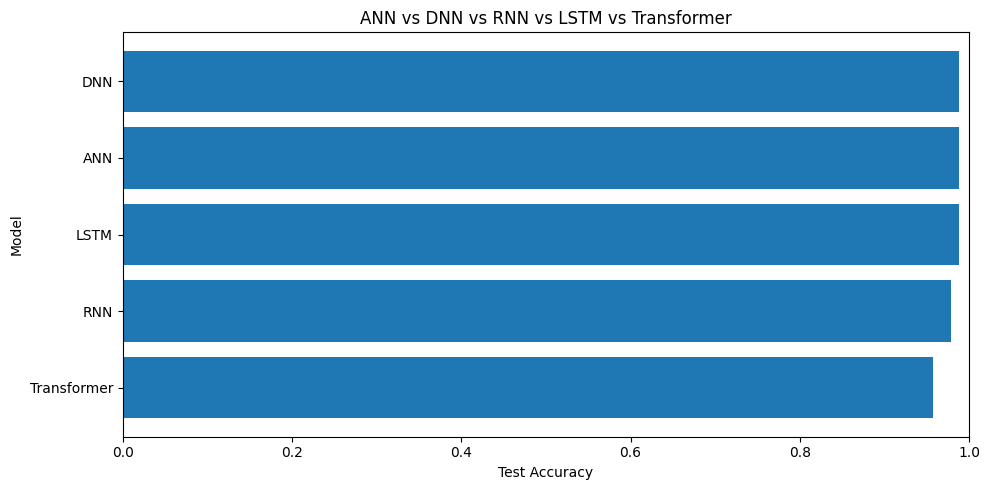

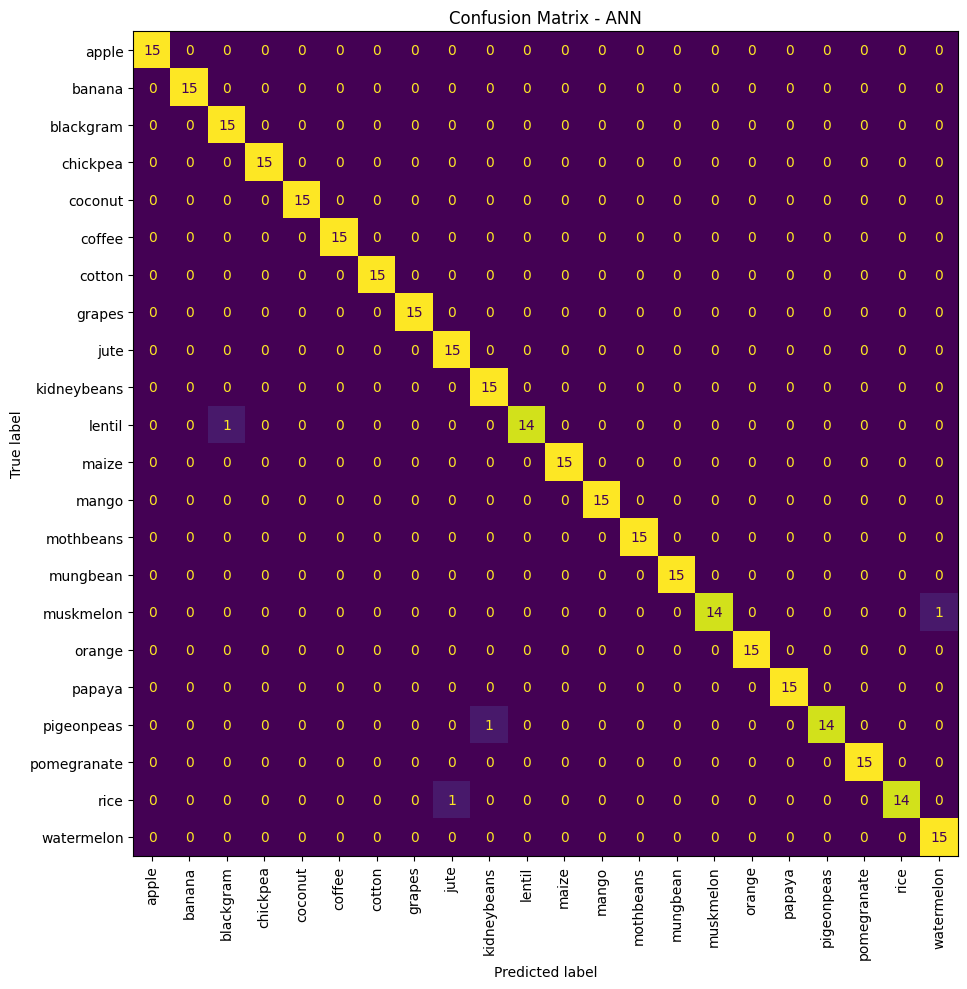

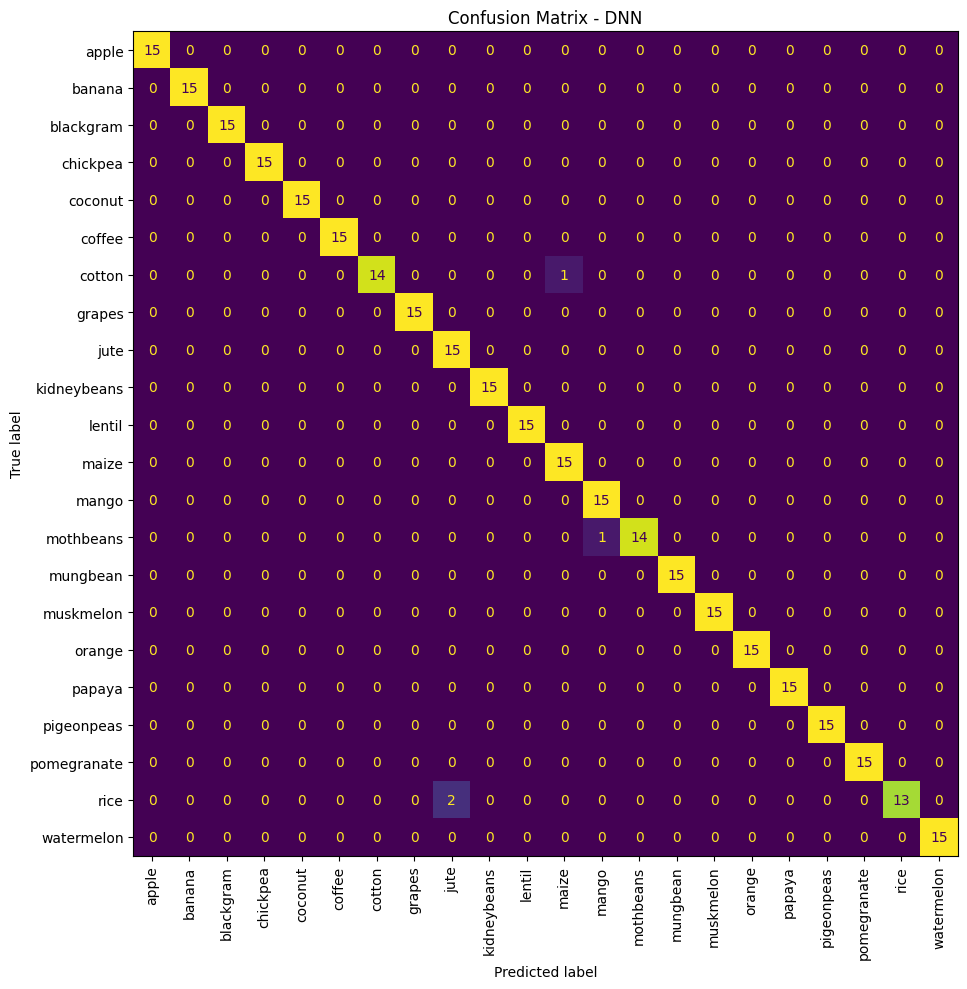

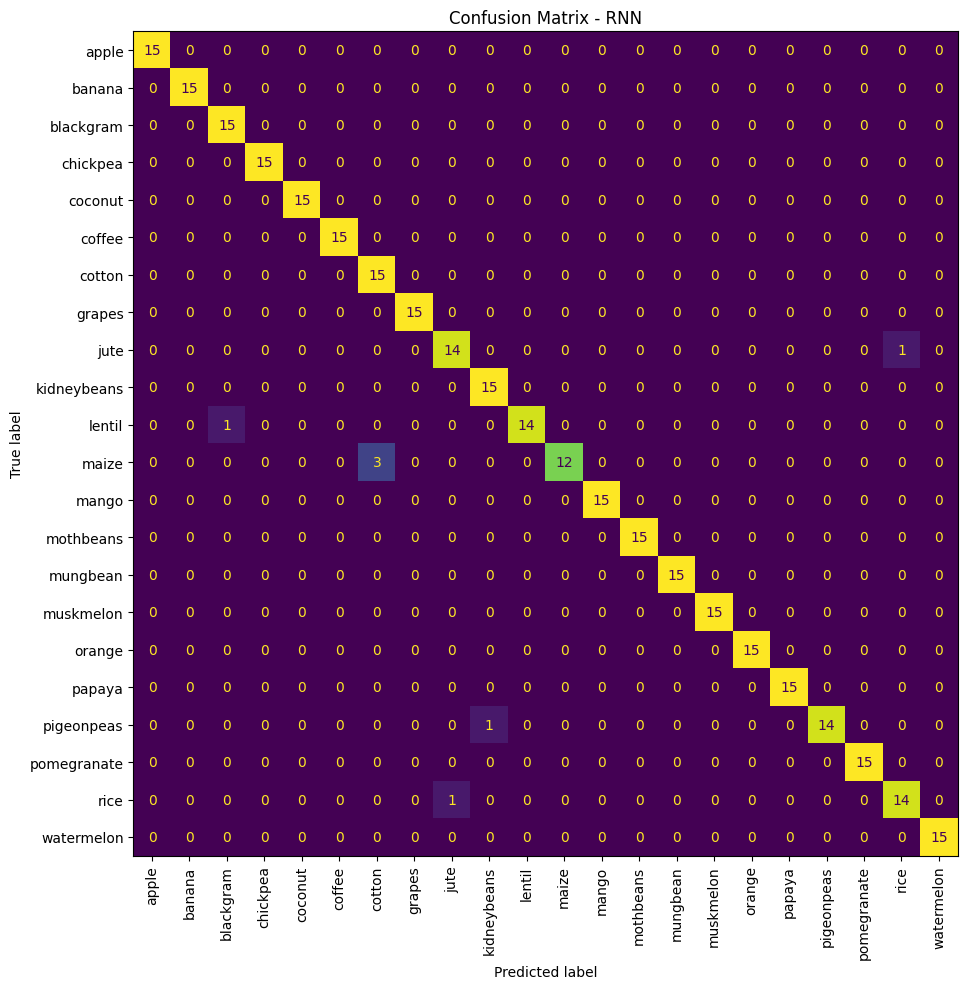

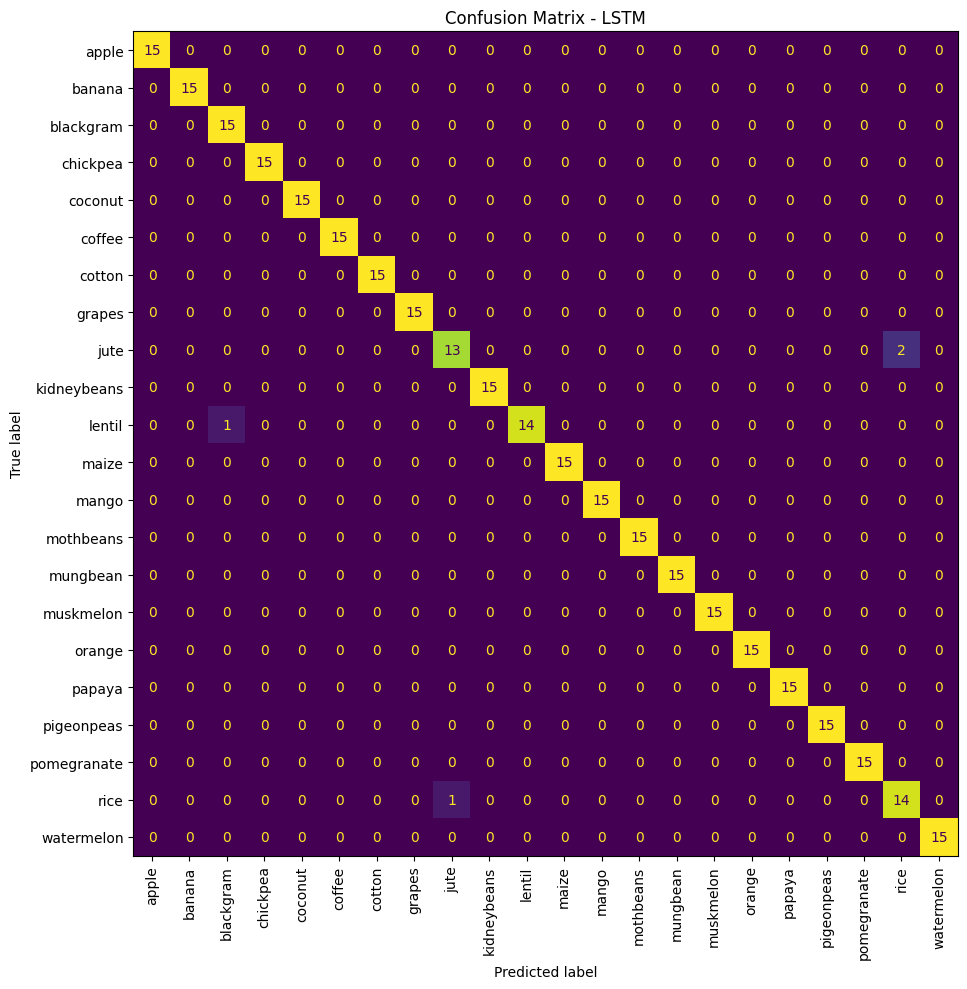

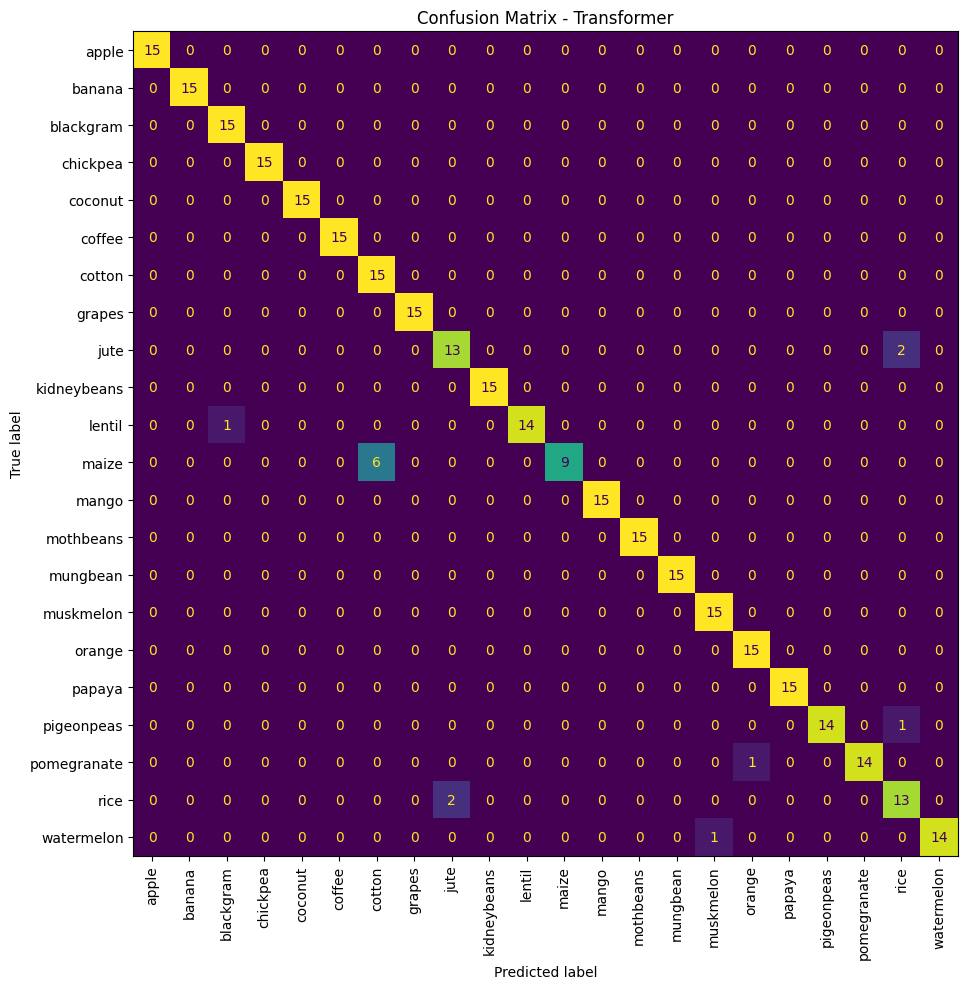

Detailed classification report for the selected model:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        15
      banana       1.00      1.00      1.00        15
   blackgram       0.94      1.00      0.97        15
    chickpea       1.00      1.00      1.00        15
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        15
      cotton       1.00      1.00      1.00        15
      grapes       1.00      1.00      1.00        15
        jute       0.94      1.00      0.97        15
 kidneybeans       0.94      1.00      0.97        15
      lentil       1.00      0.93      0.97        15
       maize       1.00      1.00      1.00        15
       mango       1.00      1.00      1.00        15
   mothbeans       1.00      1.00      1.00        15
    mungbean       1.00      1.00      1.00        15
   muskmelon       1.00      0.93      0.97        15
      orange       1.00   

In [27]:
# Model comparison plot
plt.figure(figsize=(10, 5))
plot_df = results_df.sort_values('Test Accuracy', ascending=True)
plt.barh(plot_df['Model'], plot_df['Test Accuracy'])
plt.xlabel('Test Accuracy')
plt.ylabel('Model')
plt.title('ANN vs DNN vs RNN vs LSTM vs Transformer')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# One confusion matrix per model
for name, preds in predictions.items():
    cm = confusion_matrix(y_test, preds, labels=np.arange(n_classes))
    fig, ax = plt.subplots(figsize=(12, 10))
    ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_).plot(
        ax=ax, xticks_rotation=90, values_format='d', colorbar=False
    )
    ax.set_title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.show()

print('Detailed classification report for the selected model:')
print(classification_report(
    y_test, best_preds, target_names=label_encoder.classes_, zero_division=0
))

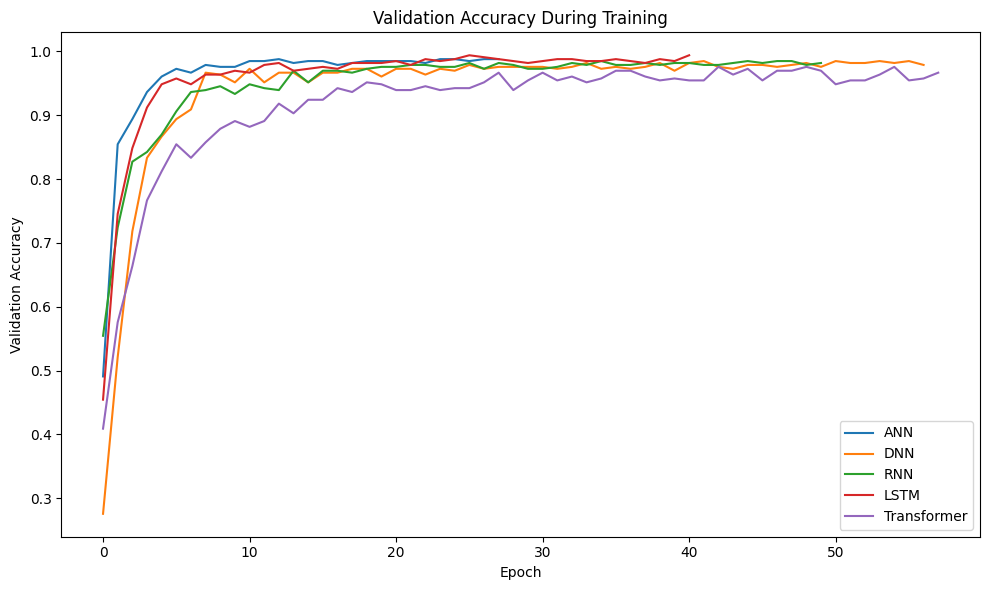

In [28]:
history_map = {
    'ANN': ann_history, 'DNN': dnn_history, 'RNN': rnn_history,
    'LSTM': lstm_history, 'Transformer': transformer_history
}

plt.figure(figsize=(10, 6))
for name, hist in history_map.items():
    plt.plot(hist.history['val_accuracy'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy During Training')
plt.legend()
plt.tight_layout()
plt.show()

,Feature,Importance
4,humidity,0.392727
6,rainfall,0.356970
0,n,0.309091
1,p,0.304242
2,k,0.281212
3,temperature,0.106667
5,ph,0.029091


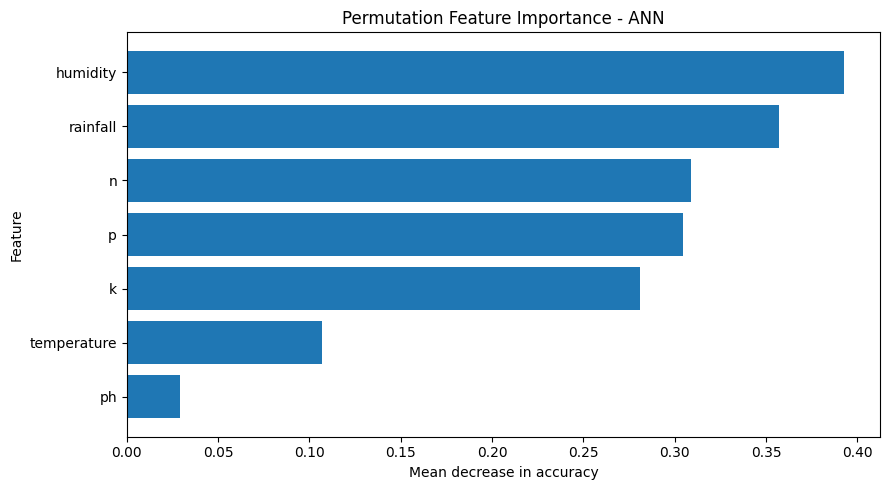

Baseline Test Accuracy: 0.9879


In [29]:
# Custom permutation importance for Keras models

def get_model_predictions(X):
    X_input = np.asarray(X)

    if best_model_name in ['RNN', 'LSTM', 'Transformer']:
        X_input = X_input.reshape(
            X_input.shape[0],
            1,
            X_input.shape[1]
        )

    return np.argmax(
        best_model.predict(X_input, verbose=0),
        axis=1
    )


def calculate_permutation_importance(X, y, n_repeats=5, random_state=42):

    rng = np.random.RandomState(random_state)

    X = np.asarray(X).copy()
    y = np.asarray(y)

    baseline_pred = get_model_predictions(X)
    baseline_accuracy = accuracy_score(y, baseline_pred)

    importances = np.zeros(X.shape[1])

    for feature_idx in range(X.shape[1]):

        scores = []

        for _ in range(n_repeats):

            X_permuted = X.copy()

            shuffled = X_permuted[:, feature_idx].copy()
            rng.shuffle(shuffled)

            X_permuted[:, feature_idx] = shuffled

            permuted_pred = get_model_predictions(X_permuted)

            permuted_accuracy = accuracy_score(
                y,
                permuted_pred
            )

            scores.append(
                baseline_accuracy - permuted_accuracy
            )

        importances[feature_idx] = np.mean(scores)

    return baseline_accuracy, importances


baseline_accuracy, feature_importances = calculate_permutation_importance(
    X_test_s,
    y_test,
    n_repeats=5,
    random_state=42
)


importance_df = pd.DataFrame({
    'Feature': MODEL_FEATURES,
    'Importance': feature_importances
}).sort_values(
    'Importance',
    ascending=False
)

display(importance_df)

plt.figure(figsize=(9, 5))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel('Mean decrease in accuracy')
plt.ylabel('Feature')

plt.title(
    f'Permutation Feature Importance - {best_model_name}'
)

plt.tight_layout()
plt.show()

print(
    f'Baseline Test Accuracy: {baseline_accuracy:.4f}'
)

In [30]:
best_model.save('best_crop_model.keras')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'encoder.pkl')
joblib.dump(profile_lookup, 'crop_mapping.pkl')
joblib.dump({
    'model_name': best_model_name,
    'model_input_type': 'sequence' if best_model_name in ['RNN', 'LSTM', 'Transformer'] else 'tabular',
    'model_features': MODEL_FEATURES,
    'sequence_length': SEQUENCE_LENGTH
}, 'model_metadata.pkl')
market_stats.to_csv('market_stats.csv', index=False)
results_df.to_csv('model_comparison.csv', index=False)
print('Saved model, scaler, encoder, crop mapping, metadata, market stats and model comparison.')

Saved model, scaler, encoder, crop mapping, metadata, market stats and model comparison.


In [34]:
def _prepare_live_input(row_dict):
    live_df = pd.DataFrame([row_dict])[MODEL_FEATURES].astype(float)
    live_scaled = scaler.transform(live_df)
    if best_model_name in ['RNN', 'LSTM', 'Transformer']:
        return live_scaled.reshape(1, 1, len(MODEL_FEATURES))
    return live_scaled


# ---- Kaggle label -> real mandi/AGMARKNET commodity name variants ----
# Kaggle's crop_df labels ("lentil", "mungbean", "pigeonpeas"...) rarely match
# AGMARKNET commodity strings verbatim ("Lentil (Masur)(Whole)", "Green Gram (Moong)",
# "Arhar (Tur/Red Gram)(Whole)"...), which is why a plain equality lookup returned NaN.
import re

CROP_MANDI_ALIASES = {
    'rice': ['paddy', 'rice', 'dhan'],
    'maize': ['maize', 'makka', 'corn'],
    'chickpea': ['bengal gram', 'gram', 'chana', 'kabuli chana', 'chickpea'],
    'kidneybeans': ['kidney bean', 'rajmash', 'rajma'],
    'pigeonpeas': ['arhar', 'tur', 'red gram', 'pigeon pea'],
    'mothbeans': ['moath', 'moth bean', 'moth'],
    'mungbean': ['green gram', 'moong', 'mung bean', 'mung'],
    'blackgram': ['black gram', 'urad', 'urd'],
    'lentil': ['lentil', 'masur'],
    'pomegranate': ['pomegranate', 'anar'],
    'banana': ['banana'],
    'mango': ['mango'],
    'grapes': ['grape'],
    'watermelon': ['water melon', 'watermelon'],
    'muskmelon': ['musk melon', 'muskmelon', 'kharbuja'],
    'apple': ['apple'],
    'orange': ['orange', 'kinnow', 'mousambi', 'mausambi', 'sweet lime'],
    'papaya': ['papaya'],
    'coconut': ['coconut'],
    'cotton': ['cotton', 'kapas'],
    'jute': ['jute'],
    'coffee': ['coffee'],
}

def _normalize_commodity(s):
    s = str(s).lower()
    s = re.sub(r'\(.*?\)', ' ', s)          # drop "(Whole)", "(Tur/Red Gram)", etc.
    s = re.sub(r'[^a-z\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s


def _lookup_market_price(crop_label, state):
    """Returns Avg_Price (Rs/quintal), Market_Score and where the number came from."""
    if 'market_stats' not in globals() or market_stats is None or len(market_stats) == 0:
        return {'Avg_Price': np.nan, 'Market_Score': np.nan, 'Price_Source': 'mandi data not loaded'}

    ms = market_stats.copy()
    if 'Commodity_clean' not in ms.columns:
        ms['Commodity_clean'] = ms['Commodity_norm'].apply(_normalize_commodity)

    aliases = [_normalize_commodity(a) for a in CROP_MANDI_ALIASES.get(crop_label, [crop_label])]

    def _match(rows):
        for alias in aliases:
            hit = rows[rows['Commodity_clean'].str.contains(alias, na=False, regex=False)]
            if len(hit):
                return hit.sort_values('N_Records', ascending=False).iloc[0]
        return None

    state_rows = ms[ms['State'].astype(str).str.lower() == str(state).lower()]
    row = _match(state_rows)
    if row is not None:
        return {'Avg_Price': float(row['Avg_Price']), 'Market_Score': float(row['Market_Score']),
                'Price_Source': f'{state} avg, {int(row["N_Records"])} records'}

    row = _match(ms)
    if row is not None:
        return {'Avg_Price': float(row['Avg_Price']), 'Market_Score': float(row['Market_Score']),
                'Price_Source': f'national avg (no {state} data), {int(row["N_Records"])} records'}

    return {'Avg_Price': np.nan, 'Market_Score': np.nan,
            'Price_Source': 'no mandi record for this crop in your uploaded file'}


def recommend_crops(city, state, district=None, api_key=OWM_API_KEY, top_k=5,
                     N=None, P=None, K=None, ph=None):
    """
    N, P, K (kg/ha) and soil pH are supplied by the caller (e.g. from a soil test,
    or typical values for the field) — neither OpenWeatherMap nor the micronutrient
    soil file used earlier in this notebook reports N/P/K/pH directly. Temperature,
    humidity and rainfall are fetched live / as historical normals for the location.
    If N/P/K/ph aren't supplied, the training data's mean is used as a rough default.
    """
    weather = fetch_weather(city, api_key)
    if weather.get('error'):
        print('Weather fetch failed:', weather['error'])
        return None
    lat, lon = weather['latitude'], weather['longitude']

    climate = {
    'temperature': weather['temperature'],
    'humidity': weather['humidity'],
    'rainfall': weather['rainfall']
     }

    used_defaults = N is None or P is None or K is None or ph is None
    row_dict = {
        'n': N if N is not None else crop_df['n'].mean(),
        'p': P if P is not None else crop_df['p'].mean(),
        'k': K if K is not None else crop_df['k'].mean(),
        'ph': ph if ph is not None else crop_df['ph'].mean(),
        'temperature': climate['temperature'],
        'humidity': climate['humidity'],
        'rainfall': climate['rainfall']
    }

    X_live = _prepare_live_input(row_dict)
    probs = best_model.predict(X_live, verbose=0)[0]
    top_idx = np.argsort(probs)[-top_k:][::-1]
    crops = label_encoder.inverse_transform(top_idx)

    print('=' * 60)
    print('              AI CROP RECOMMENDATION SYSTEM')
    print('=' * 60)
    print(f'Location: {city}, {state}' + (f', {district}' if district else ''))
    print(f'Live weather: {weather["temperature"]:.1f}°C, {weather["humidity"]:.0f}% humidity')
    print(f'Soil input: N={row_dict["n"]:.0f}, P={row_dict["p"]:.0f}, K={row_dict["k"]:.0f}, pH={row_dict["ph"]:.2f}'
          + (' (defaults used — pass N/P/K/ph from a real soil test for accuracy)' if used_defaults else ''))
    print(f'Model: {best_model_name} | Test accuracy: {results_df.loc[0, "Test Accuracy"]:.2%}')
    print()

    out = []
    for rank, (crop, idx) in enumerate(zip(crops, top_idx), 1):
        fit_score = suitability_score(row_dict, profile_lookup[crop], FEATURE_COLS)
        market = _lookup_market_price(crop, state)

        line = (f'{rank}. {crop.title()} | Model probability: {probs[idx]*100:.1f}% '
                f'| Suitability fit: {fit_score*100:.1f}%')
        if not np.isnan(market['Avg_Price']):
            line += f" | Avg price: Rs {market['Avg_Price']:.0f}/quintal ({market['Price_Source']})"
        else:
            line += f" | Price: {market['Price_Source']}"
        print(line)

        out.append({
            'Crop': crop.title(),
            'Model_Probability': round(float(probs[idx]) * 100, 2),
            'Suitability_Fit': round(fit_score * 100, 2),
            'Avg_Price_Rs_per_quintal': round(market['Avg_Price'], 2) if not np.isnan(market['Avg_Price']) else np.nan,
            'Market_Score': round(market['Market_Score'], 2) if not np.isnan(market['Market_Score']) else np.nan,
            'Price_Source': market['Price_Source']
        })
    return pd.DataFrame(out)

In [35]:
result = recommend_crops(
    city="Delhi",
    state="Delhi",
    district="New Delhi",
    N=90, P=42, K=43, ph=6.5,   # example soil-test values — replace with real ones
    top_k=5
)

display(result)

              AI CROP RECOMMENDATION SYSTEM
Location: Delhi, Delhi, New Delhi
Live weather: 35.0°C, 41% humidity
Soil input: N=90, P=42, K=43, pH=6.50
Model: ANN | Test accuracy: 98.79%

1. Mothbeans | Model probability: 99.4% | Suitability fit: 19.3% | Price: no mandi record for this crop in your uploaded file
2. Coffee | Model probability: 0.3% | Suitability fit: 19.4% | Price: no mandi record for this crop in your uploaded file
3. Blackgram | Model probability: 0.1% | Suitability fit: 4.5% | Avg price: Rs 2003/quintal (national avg (no Delhi data), 6783 records)
4. Chickpea | Model probability: 0.1% | Suitability fit: 1.6% | Price: no mandi record for this crop in your uploaded file
5. Kidneybeans | Model probability: 0.1% | Suitability fit: 5.3% | Price: no mandi record for this crop in your uploaded file


,Crop,Model_Probability,Suitability_Fit,Avg_Price_Rs_per_quintal,Market_Score,Price_Source
0,Mothbeans,99.43,19.33,NaN,NaN,no mandi record for this crop in your uploaded...
1,Coffee,0.27,19.44,NaN,NaN,no mandi record for this crop in your uploaded...
2,Blackgram,0.14,4.52,2002.75,20.84,"national avg (no Delhi data), 6783 records"
3,Chickpea,0.07,1.61,NaN,NaN,no mandi record for this crop in your uploaded...
4,Kidneybeans,0.06,5.33,NaN,NaN,no mandi record for this crop in your uploaded...


In [36]:
result = recommend_crops(
    city="Lucknow",
    state="Uttar Pradesh",
    district="Lucknow",
    top_k=15
)

display(result)

              AI CROP RECOMMENDATION SYSTEM
Location: Lucknow, Uttar Pradesh, Lucknow
Live weather: 33.0°C, 52% humidity
Soil input: N=51, P=53, K=48, pH=6.47 (defaults used — pass N/P/K/ph from a real soil test for accuracy)
Model: ANN | Test accuracy: 98.79%

1. Mothbeans | Model probability: 97.9% | Suitability fit: 26.3% | Price: no mandi record for this crop in your uploaded file
2. Blackgram | Model probability: 0.9% | Suitability fit: 7.8% | Avg price: Rs 1549/quintal (Uttar Pradesh avg, 1005 records)
3. Lentil | Model probability: 0.5% | Suitability fit: 11.6% | Price: no mandi record for this crop in your uploaded file
4. Grapes | Model probability: 0.4% | Suitability fit: 0.0% | Price: no mandi record for this crop in your uploaded file
5. Chickpea | Model probability: 0.2% | Suitability fit: 1.8% | Price: no mandi record for this crop in your uploaded file
6. Mango | Model probability: 0.1% | Suitability fit: 4.8% | Price: no mandi record for this crop in your uploaded file


,Crop,Model_Probability,Suitability_Fit,Avg_Price_Rs_per_quintal,Market_Score,Price_Source
0,Mothbeans,97.91,26.32,NaN,NaN,no mandi record for this crop in your uploaded...
1,Blackgram,0.90,7.81,1548.73,21.36,"Uttar Pradesh avg, 1005 records"
2,Lentil,0.47,11.57,NaN,NaN,no mandi record for this crop in your uploaded...
3,Grapes,0.40,0.04,NaN,NaN,no mandi record for this crop in your uploaded...
4,Chickpea,0.20,1.80,NaN,NaN,no mandi record for this crop in your uploaded...
5,Mango,0.07,4.81,NaN,NaN,no mandi record for this crop in your uploaded...
6,Pigeonpeas,0.02,22.31,NaN,NaN,no mandi record for this crop in your uploaded...
7,Kidneybeans,0.01,5.10,NaN,NaN,no mandi record for this crop in your uploaded...
8,Muskmelon,0.01,2.65,NaN,NaN,no mandi record for this crop in your uploaded...
9,Papaya,0.01,8.76,NaN,NaN,no mandi record for this crop in your uploaded...
